# PhotoRing — test Colab exports locally

Two standalone cells below (same style as **pyPplusS / Colab** and **Pryngles / Colab** in the simulator).
Edit the numbers at the top of each cell, then run it.

Install once if needed:

```bash
pip install pyppluss matplotlib "rebound>=4.0,<4.7" pryngles
```

Pryngles needs Rebound &lt; 4.7 (the `hash=` argument was removed in 4.7+).

In [1]:
%pip install pyppluss matplotlib "rebound>=4.0,<4.7" pryngles

Note: you may need to restart the kernel to use updated packages.


## Pryngles (`System.compute_lightcurve`)

First run can take a minute (spangle integration).

In [8]:
# %pip install -q "rebound>=4.0,<4.7" pryngles matplotlib

import numpy as np
import matplotlib.pyplot as plt
import pryngles as pr
from pryngles import Consts, System

# --- PRisma configuration (sky-plane parameters from the web app) ---
p = 0.084                 # planet radius [R★]
fi = 1.58                 # inner ring [Rp]
fe = 2.35                 # outer ring [Rp]
tilt_deg = 25.0           # θ_R [deg] sky-plane position angle / tilt
ir_deg = 55.0             # i_R [deg] sky-plane inclination (0=face-on, 90=edge-on)
b = 0.25                  # impact parameter [R★]
alpha = 0.36787944117144233  # ring transmission along the normal
tau = 1.0                 # optical depth τ = −ln α
mstar = 1.0               # M★ [M☉]
rstar = 1.0               # R★ [R☉]
mpjup = 0.2994            # Mp [Mjup] (not used for transit LC)
a_au = 0.9999974887698985 # a [AU]
porb = 365.25             # Porb [days]
a_rs = 215.03148902581856 # a/R★

# --- Conversion: sky-plane projection (app) → orbital orientation (Pryngles) ---
# The web app and pyPplusS define the ring orientation on the sky plane:
#   ir_deg   : apparent inclination relative to line of sight (0°=face-on, 90°=edge-on)
#   tilt_deg : position angle / tilt of the ring on the sky
#
# Pryngles defines the ring normal in 3D orbital coordinates:
#   n_equ = [sin(i)*cos(roll), sin(i)*sin(roll), cos(i)]
# For a transit observer looking along +x (lambda=0, beta=0), the sky plane is (y, z):
#   cos(ir_sky)   = |n_x| = sin(i)*cos(roll)
#   tan(tilt_sky) = n_y / n_z = sin(i)*sin(roll) / cos(i)
# Inverting for Pryngles physical orbital parameters (i, roll):
_ir_rad   = np.radians(ir_deg)
_tilt_rad = np.radians(tilt_deg)
_cos_i_pryngles = np.sin(_ir_rad) * np.cos(_tilt_rad)
i_pryngles      = float(np.arccos(np.clip(_cos_i_pryngles, -1.0, 1.0)))
roll_pryngles   = float(np.arctan2(np.sin(_ir_rad) * np.sin(_tilt_rad), np.cos(_ir_rad)))

print(f"Sky-plane projection (app / pyPplusS): ir = {ir_deg:.2f}°, tilt = {tilt_deg:.2f}°")
print(f"Orbital orientation (Pryngles):         i = {np.degrees(i_pryngles):.2f}°, roll = {np.degrees(roll_pryngles):.2f}°")

nspangles = 250  # more spangles → smoother LC, slower run
OBSERVER = (0.0, 0.0)  # ecliptic (λ, β) in degrees → look along +X; pass every compute_lightcurve call

sys = System(units=["au", "msun", "day"])
star = sys.add(
    kind="Star",
    name="Star",
    m=mstar,
    radius=rstar * Consts.rsun / sys.ul,
    limb_coeffs=[0.0, 0.0],
    nspangles=nspangles,
)

orb_inc = float(np.arccos(np.clip(b / a_rs, -1.0, 1.0)))
planet = sys.add(
    kind="Planet",
    parent=star,
    name="Planet",
    m=1e-5,
    a=a_au,
    e=0.0,
    inc=orb_inc,
    radius=p * rstar * Consts.rsun / sys.ul,
    nspangles=nspangles,
)
print(orb_inc*180/np.pi, p * rstar * Consts.rsun / sys.ul)
ring = sys.add(
    kind="Ring",
    parent=planet,
    name="Ring",
    fi=fi,
    fe=fe,
    i=i_pryngles,
    roll=roll_pryngles,
    tau_gray_optical=tau,
    nspangles=nspangles,
)
lc_bodies = ["Planet", "Ring"]
sys.initialize_simulation()
sys.spangle_system()

"""
t_scan = np.linspace(-2.0, 2.0, 401)
f_scan = sys.compute_lightcurve(
    t_scan, effects=["transit"], bodies=lc_bodies, observer=OBSERVER,
)["total_flux"]
in_transit = f_scan < 0.999
t_mid = (
    0.5 * (float(t_scan[in_transit][0]) + float(t_scan[in_transit][-1]))
    if np.any(in_transit)
    else float(t_scan[np.argmin(f_scan)])
)

t_hours = np.linspace(-8.624753722766377, 8.624753722766377, 181)
times = t_mid + t_hours / 24.0
flux = sys.compute_lightcurve(
    times, effects=["transit"], bodies=lc_bodies, observer=OBSERVER,
)["total_flux"]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(t_hours, flux, color="#66dfd0", lw=2)
ax.set_xlabel("Time from mid-transit [hours]")
ax.set_ylabel("Relative flux")
ax.set_title(f"Pryngles ringed transit (i={np.degrees(i_pryngles):.1f}°, roll={np.degrees(roll_pryngles):.1f}°)")
ax.grid(True, alpha=0.25)
plt.show()

print(f"min flux = {flux.min():.6f}; out-of-transit start/end = {flux[0]:.4f}, {flux[-1]:.4f}")

# Keep a named reference before the pyPplusS cell overwrites 'flux'
flux_pryngles = flux.copy()
t_hours_pryngles = t_hours.copy()
"""

Sky-plane projection (app / pyPplusS): ir = 55.00°, tilt = 25.00°
Orbital orientation (Pryngles):         i = 42.06°, roll = 31.11°
89.93338674177406 0.00039063924992082126


'\nt_scan = np.linspace(-2.0, 2.0, 401)\nf_scan = sys.compute_lightcurve(\n    t_scan, effects=["transit"], bodies=lc_bodies, observer=OBSERVER,\n)["total_flux"]\nin_transit = f_scan < 0.999\nt_mid = (\n    0.5 * (float(t_scan[in_transit][0]) + float(t_scan[in_transit][-1]))\n    if np.any(in_transit)\n    else float(t_scan[np.argmin(f_scan)])\n)\n\nt_hours = np.linspace(-8.624753722766377, 8.624753722766377, 181)\ntimes = t_mid + t_hours / 24.0\nflux = sys.compute_lightcurve(\n    times, effects=["transit"], bodies=lc_bodies, observer=OBSERVER,\n)["total_flux"]\n\nfig, ax = plt.subplots(figsize=(8, 3.6))\nax.plot(t_hours, flux, color="#66dfd0", lw=2)\nax.set_xlabel("Time from mid-transit [hours]")\nax.set_ylabel("Relative flux")\nax.set_title(f"Pryngles ringed transit (i={np.degrees(i_pryngles):.1f}°, roll={np.degrees(roll_pryngles):.1f}°)")\nax.grid(True, alpha=0.25)\nplt.show()\n\nprint(f"min flux = {flux.min():.6f}; out-of-transit start/end = {flux[0]:.4f}, {flux[-1]:.4f}")\n\n# Ke

## pyPplusS (`LC_ringed`)

Analytic P+S model (Rein & Ofir 2019). Same geometry as the web app export.

opacity = 0.825084, rin = 0.132720 R★, rout = 0.197400 R★
Rein & Ofir (2019), MNRAS, 490, 1111. Package: pip install pyppluss


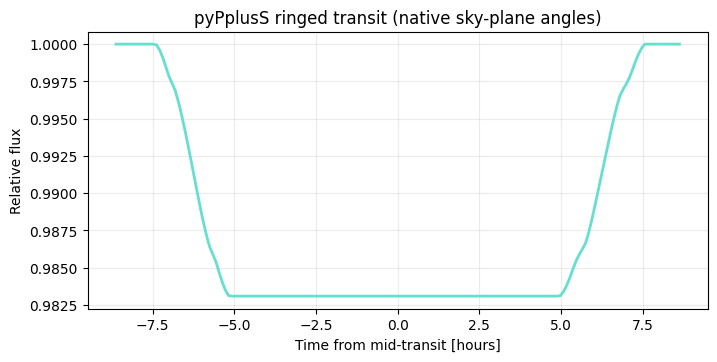

In [2]:
# PhotoRing → pyPplusS (Rein & Ofir 2019)
# Paste this cell into Google Colab:
# https://colab.research.google.com/
# Generated from the current PRisma configuration.

# Uncomment in Colab if pyppluss is not installed yet:
# %pip install -q pyppluss matplotlib

import numpy as np

# Colab ships NumPy 2, which removed np.NaN. pyPplusS still uses that name.
if not hasattr(np, "NaN"):
    np.NaN = np.nan

import matplotlib.pyplot as plt
from pyppluss.segment_models import LC_ringed

# --- PRisma configuration (exact parameters from the web app) ----------------
p        = 0.084                 # planet radius [R★]
fi       = 1.58                  # inner ring [Rp]
fe       = 2.35                  # outer ring [Rp]
tilt_deg = 25.0                  # θ_R [deg] sky-plane position angle / tilt
ir_deg   = 55.0                  # i_R [deg] sky-plane inclination (0=face-on, 90=edge-on)
b        = 0.25                  # impact parameter [R★]
alpha    = 0.36787944117144233   # normal ring transmission exp(-tau_normal)
mstar    = 1.0                   # M★ [M☉]
rstar    = 1.0                   # R★ [R☉]
mpjup    = 0.2994                # Mp [Mjup]
a_au     = 0.9999974887698985    # a [AU]
porb     = 365.25                # Porb [days]
a_rs     = 215.03148902581856    # a/R★

# pyPplusS natively uses sky-plane projected lengths and angles:
#   ir   → apparent inclination to line of sight (0 = face-on)
#   tilt → position angle of the ring semi-major axis on the sky
rp   = p
rin  = p * fi
rout = p * fe
ir   = np.radians(ir_deg)
tilt = np.radians(tilt_deg)
cos_i = max(0.0, float(np.cos(ir)))

# Opacity = blocked fraction along projected line of sight: 1 − α^{1/cos i_R}
if cos_i <= 1e-6 or alpha >= 1.0:
    opacity = 0.0
elif alpha <= 0.0:
    opacity = 1.0
else:
    opacity = 1.0 - alpha ** (1.0 / cos_i)

# --- Time / position axis ---------------------------------------------------
t_hours = np.linspace(-8.624753722766377, 8.624753722766377, 181)
x = t_hours * 0.15406116229318004
y = np.full_like(x, b)

# --- Compute light curve -----------------------------------------------------
ones = np.ones_like(x)
flux = LC_ringed(
    ones * rp,
    ones * rin,
    ones * rout,
    x,
    y,
    ir,
    tilt,
    opacity,
    0.0,
    0.0,
    0.0,
    0.0,
)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(t_hours, flux, color="#66dfd0", lw=2)
ax.set_xlabel("Time from mid-transit [hours]")
ax.set_ylabel("Relative flux")
ax.set_title("pyPplusS ringed transit (native sky-plane angles)")
ax.grid(True, alpha=0.25)
plt.show()

print(f"opacity = {opacity:.6f}, rin = {rin:.6f} R★, rout = {rout:.6f} R★")
print("Rein & Ofir (2019), MNRAS, 490, 1111. Package: pip install pyppluss")


## Comparación: Pryngles vs pyPplusS

Superposición de ambas curvas de luz usando los mismos parámetros de configuración.

Modelo                             min flux   depth [ppm]
----------------------------------------------------------
pyPplusS (sky-plane ir=55°, tilt=25°)   0.983083       16916.9
Pryngles (orbit i=42.1°, roll=31.1°)   0.983137       16862.9
----------------------------------------------------------
Diferencia en profundidad: 54.0 ppm (0.32%)
Max |residual|  =  2739.7 ppm
RMS  residual   =   761.7 ppm


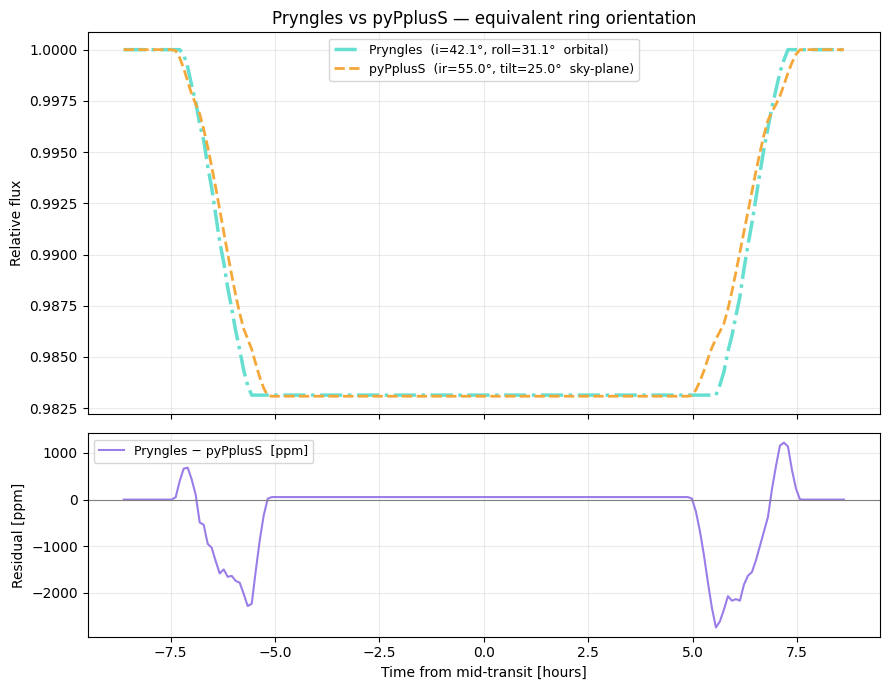

In [3]:
# ── Comparison: Pryngles vs pyPplusS ─────────────────────────────────────────
# Runs AFTER the two cells above. Both models describe the same physical system:
#   Web app & pyPplusS : sky-plane projection (ir = 55.0°, tilt = 25.0°)
#   Pryngles           : orbital orientation  (i = 42.06°, roll = 31.11°, converted)

import numpy as np
import matplotlib.pyplot as plt

flux_pyppluss = flux.copy()
residuals = flux_pryngles - flux_pyppluss

depth_pryngles = (1.0 - flux_pryngles.min()) * 1e6
depth_pyppluss = (1.0 - flux_pyppluss.min()) * 1e6

print(f"{'Modelo':<32s} {'min flux':>10}  {'depth [ppm]':>12}")
print("-" * 58)
print(f"{'pyPplusS (sky-plane ir=55°, tilt=25°)':<32s} {flux_pyppluss.min():>10.6f}  {depth_pyppluss:>12.1f}")
print(f"{'Pryngles (orbit i=42.1°, roll=31.1°)':<32s} {flux_pryngles.min():>10.6f}  {depth_pryngles:>12.1f}")
print("-" * 58)
print(f"Diferencia en profundidad: {abs(depth_pryngles - depth_pyppluss):.1f} ppm ({abs(depth_pryngles - depth_pyppluss)/depth_pyppluss*100:.2f}%)")
print(f"Max |residual|  = {np.max(np.abs(residuals))*1e6:7.1f} ppm")
print(f"RMS  residual   = {np.sqrt(np.mean(residuals**2))*1e6:7.1f} ppm")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1.6]})

ax1.plot(t_hours_pryngles, flux_pryngles,
         color="#66dfd0", lw=2.5, ls="-.",
         label=f"Pryngles  (i={np.degrees(i_pryngles):.1f}°, roll={np.degrees(roll_pryngles):.1f}°  orbital)")
ax1.plot(t_hours_pryngles, flux_pyppluss, color="#f4a83a", lw=2.0, ls="--",
         label=f"pyPplusS  (ir={ir_deg:.1f}°, tilt={tilt_deg:.1f}°  sky-plane)")
ax1.set_ylabel("Relative flux")
ax1.set_title("Pryngles vs pyPplusS — equivalent ring orientation")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

ax2.plot(t_hours_pryngles, residuals * 1e6,
         color="#9b7de8", lw=1.5, label="Pryngles − pyPplusS  [ppm]")
ax2.axhline(0, color="gray", lw=0.8)
ax2.set_xlabel("Time from mid-transit [hours]")
ax2.set_ylabel("Residual [ppm]")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()
